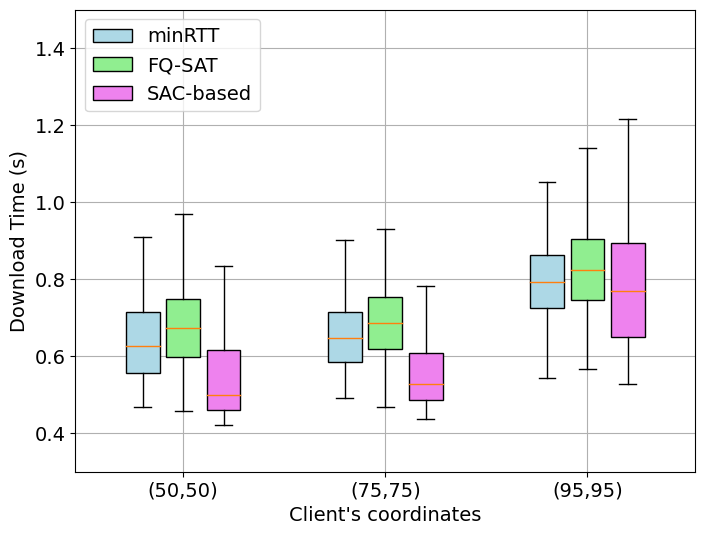

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

column_names = ['Download Time']
schedules = ['rtt', 'fuzzyqsat', 'sac']
var = 0
los = 0

# List to hold all download time data
all_download_times = {sch: [] for sch in schedules}

# Common scenarios
scenarios = [
    "none", "dif1", "dif2"
]
scenarios_label = [
    "(50,50)", "(75,75)", "(95,95)"
]

# Đọc dữ liệu từ file và lưu vào dictionary
for sch in schedules:
    for scenario in scenarios:
        # Load the data from the CSV file
        data = pd.read_csv(f'../output/{scenario}-1-2MB-0-0-50-10-{var}-{los}-{sch}-result3.csv', names=column_names)
        
        # Extract and store the Download Time column
        all_download_times[sch].append(data['Download Time'] / 1000)

# Tạo boxplot
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})

# Chuẩn bị dữ liệu và vị trí cho boxplot
positions = []
base_position = 1

colors = {'rtt': 'lightblue', 'fuzzyqsat': 'lightgreen', 'sac': 'violet', 'random': 'gray'}
boxplots = []

# Điều chỉnh vị trí để các box không chồng lên nhau
group_spacing = 1.5  # Khoảng cách giữa các nhóm kịch bản
box_spacing = 0.3    # Khoảng cách giữa các box trong cùng một nhóm
width = 0.25          # Độ rộng của mỗi boxplot

# Tính toán vị trí cho từng boxplot
for i, sch in enumerate(schedules):
    # Xác định vị trí cho mỗi nhóm boxplot, cộng thêm khoảng cách giữa các nhóm
    positions = [j * group_spacing + i * box_spacing for j in range(len(scenarios))]
    
    # Vẽ boxplot cho từng thuật toán
    box = plt.boxplot([all_download_times[sch][j] for j in range(len(scenarios))], 
                      positions=positions,
                      widths=width, patch_artist=True, 
                      flierprops=dict(marker='o' if sch == 'rtt' else 'x', markersize=5), showfliers=False)
    for patch in box['boxes']:
        patch.set_facecolor(colors[sch])
    boxplots.append(box)

# Đặt x-ticks và nhãn cho trục x
plt.xticks([i * group_spacing + (len(schedules) - 1) * box_spacing / 2 for i in range(len(scenarios))], scenarios_label)
plt.xlabel("Client's coordinates")
plt.ylabel('Download Time (s)')
plt.grid(True)

# Thêm chú thích
plt.legend([box["boxes"][0] for box in boxplots], ['minRTT', 'FQ-SAT', 'SAC-based'], loc='upper left')
plt.ylim(0.3, 1.5)

# Hiển thị biểu đồ
# plt.show()
plt.savefig('boxplot_download_time.pdf', format='pdf')


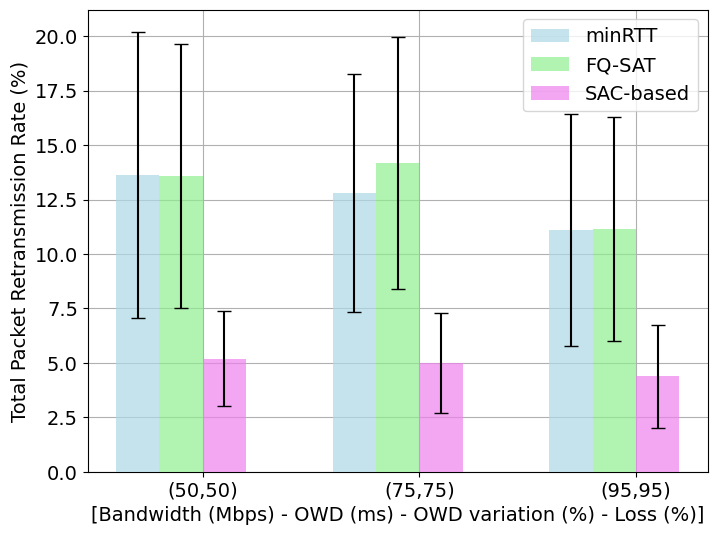

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# schedules = ['random', 'rtt', 'fuzzyqsat', 'sac']
# var = 0
# los = 0
# # Common scenarios
# scenarios = [
#     "5-10", "5-15", "10-10", "10-15", "30-10"
# ]
# scenarios_label = [
#     "5-10", "5-15", "10-10", "10-15", "30-10"
# ]

column_names = ['sRTT_1', 'RestranPacket_1', 'LostPacket_1', 'sRTT_2', 'RestranPacket_2', 'LostPacket_2']


# Color scheme based on scheduling algorithm
colors = {'rtt': 'lightblue', 'fuzzyqsat': 'lightgreen', 'sac': 'violet', 'random': 'gray'}

# List to hold all download time data and standard deviations
all_download_times = {sch: [] for sch in schedules}
all_lower_errors = {sch: [] for sch in schedules}  # Lower error values (clipped to 0)
all_upper_errors = {sch: [] for sch in schedules}  # Upper error values

# Read data from file and store it in the dictionary
for sch in schedules:
    for scenario in scenarios:
        # Load the data from the CSV file
        data = pd.read_csv(f'../output/{scenario}-1-2MB-0-0-50-10-{var}-{los}-{sch}-statistic.csv', names=column_names)
        
        # Calculate the mean and standard deviation of retransmissions
        total_retransmissions = data['RestranPacket_1'] + data['RestranPacket_2']
        mean_retransmissions = total_retransmissions.mean()
        std_retransmissions = total_retransmissions.std()

        # Calculate lower and upper error limits
        lower_error = max(0, mean_retransmissions - std_retransmissions)  # Clip lower bound to 0
        upper_error = mean_retransmissions + std_retransmissions

        # Store the mean and errors
        all_download_times[sch].append(mean_retransmissions)
        all_lower_errors[sch].append(mean_retransmissions - lower_error)
        all_upper_errors[sch].append(upper_error - mean_retransmissions)

# Create a bar chart with error bars
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 14, 'font.family': 'sans-serif'})

# Set positions for groups and bar width
bar_width = 0.2
index = np.arange(len(scenarios))  # Number of scenarios

# Plot bars for each schedule with custom colors and error bars
for i, sch in enumerate(schedules):
    plt.bar(index + i * bar_width, all_download_times[sch], bar_width,
            color=colors[sch],  # Set color based on the schedule
            yerr=[all_lower_errors[sch], all_upper_errors[sch]],  # Custom lower and upper error limits
            capsize=5, label=sch.capitalize(), alpha=0.7, zorder=3)

# Set labels, ticks, and legend
plt.xlabel("[Bandwidth (Mbps) - OWD (ms) - OWD variation (%) - Loss (%)]")
plt.ylabel('Total Packet Retransmission Rate (%)')
# plt.title('Packet Retransmission Rate by Scheduling Algorithm and Scenario with Error Bars')
plt.xticks(index + bar_width * 1.5, scenarios_label)
plt.legend(['minRTT', 'FQ-SAT', 'SAC-based'], loc='upper right')

# Show the bar chart with grid and error bars
plt.grid(True)
plt.show()
